# Test: PSA Adsorbedor 1D — Modelo de pared dinámica (shell-tube)

Verifica el modelo **shell-tube** para el adsorbedor: el vector de estado se amplía con
las temperaturas de pared por celda `Tw(z,t)` y el ODE acopla gas↔pared dinámicamente.
El sólido adsorbente `Ts` y la pared metálica `Tw` son entidades distintas.

## Qué se prueba

| Test | Descripción |
|------|-------------|
| TEST 1 | Shell-tube activo — exterior adiabático, verificación de sv layout y `_Tw_results` |
| TEST 2 | Shell-tube activo — `ambient_htc` exterior, pérdida de calor al ambiente |
| TEST 3 | Comparación ON vs OFF — inercia térmica de la pared retrasa la respuesta |
| TEST 4 | Conducción axial en pared — perfil Tw escalonado se suaviza por difusión |
| TEST 5 | Compatibilidad regresiva — sin `wall_config`, sv y resultados sin cambios |

## Layout del vector de estado

```
sin shell-tube : sv = [C(nc·N), q(nc·N), Hg(N), Ts(N)]       tamaño 2·nc·N + 2·N
con shell-tube : sv = [C(nc·N), q(nc·N), Hg(N), Ts(N), Tw(N)] tamaño 2·nc·N + 3·N
```

El atributo `col._Tw_results` de shape `(n_t, N)` está presente solo cuando
`wall_config` se incluye en `params`.

## 1. Imports

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.utils.isotherm_fitting import fit_single_T
from src.utils.isotherm_models  import arrh

from src.units.adsorber.config.gas_props  import build_gas_prop_config
from src.units.adsorber.config.adsorbent  import build_adsorbent_config
from src.units.adsorber.config.transport  import build_transport_config
from src.units.adsorber.config.thermal_bc import build_thermal_bc_config
from src.units.adsorber.config.boundary_c import build_boundary_c_config
from src.units.adsorber.config.initial_c  import build_initial_c_config
from src.units.adsorber.config.wall_c     import build_wall_config
from src.units.adsorber.state             import pack_state_vector, build_sv0_from_results

from src.solvers.runner_adsorption import run_step
from src.postprocessing.adsorber_balances import balance_report

DB_PATH   = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
DB_SOLID  = os.path.join(ROOT, "materials", "solids", "soliddb.txt")
DATA_PATH = os.path.join(os.getcwd(), "data", "Zeolite13X.csv")

print("Imports OK")
print("gasdb existe  :", os.path.isfile(DB_PATH))
print("soliddb existe:", os.path.isfile(DB_SOLID))
print("datos existen :", os.path.isfile(DATA_PATH))

Imports OK
gasdb existe  : True
soliddb existe: True
datos existen : True


## 2. Isotermas (igual que test_psa_01)

In [2]:
df_iso = pd.read_csv(DATA_PATH)
P_CO2  = df_iso["Pressure_CO2 (bar)"].dropna().values
q_CO2  = df_iso["Uptake_CO2 (mol/kg)"].dropna().values
P_CH4  = df_iso["Pressure_CH4 (bar)"].dropna().values
q_CH4  = df_iso["Uptake_CH4 (mol/kg)"].dropna().values

T_REF  = 298.15
dH_CO2 = 31.164e3
dH_CH4 =  9.856e3

iso_CO2_P, _, _, _ = fit_single_T(P_CO2, q_CO2)
iso_CH4_P, _, _, _ = fit_single_T(P_CH4, q_CH4)

def iso_CO2_PT(P_bar, T_K):
    return iso_CO2_P(np.asarray(P_bar) * arrh(float(T_K), dH_CO2, T_REF))

def iso_CH4_PT(P_bar, T_K):
    return iso_CH4_P(np.asarray(P_bar) * arrh(float(T_K), dH_CH4, T_REF))

def iso_fn(P_part_list, Ts):
    Ts_arr = np.asarray(Ts, dtype=float)
    N_loc  = len(Ts_arr)
    q_eq   = np.zeros((2, N_loc), dtype=float)
    for n in range(N_loc):
        q_eq[0, n] = iso_CO2_PT(float(P_part_list[0][n]), Ts_arr[n])
        q_eq[1, n] = iso_CH4_PT(float(P_part_list[1][n]), Ts_arr[n])
    return q_eq

print("Isotermas OK")

Isotermas OK


## 3. Parámetros comunes del sistema

In [3]:
# ── Geometría ──────────────────────────────────────────────────────────────────
N    = 21
L    = 1.35
Di   = 0.30
Do   = 0.35
dz   = L / N
Ai   = 0.25 * np.pi * Di**2
Pi   = np.pi * Di
Po   = np.pi * Do
e_wall = (Do - Di) / 2.0

# ── Adsorbente ────────────────────────────────────────────────────────────────
nc         = 2
SPECIES    = ["CO2", "CH4"]
epsi       = 0.37
D_particle = 12.0e-4
rho_s      = 3200.0
Cp_s       = 1200.0
k_s        = 10.0
tau_pore   = 3.0
r_pore     = 1.0e-9
dH_ads     = np.array([dH_CO2, dH_CH4])

# ── Condiciones de operación ──────────────────────────────────────────────────
P_inlet  = 9.5
P_outlet = 9.0
T_feed   = 323.0
y_feed   = np.array([0.33, 0.67])
Q_feed   = 0.05 * Ai
Cv_in    = 2.5e-1
Cv_out   = 1.5

# ── Solver ────────────────────────────────────────────────────────────────────
RTOL   = 1.0e-8
ATOL   = 1.0e-10
N_SEC  = 20
T_MAX  = 300.0

def _build_base_configs(mode_tbc, **tbc_kwargs):
    """Helper: construye todos los configs base reutilizables."""
    prop_gas = build_gas_prop_config(
        species=SPECIES, mode="constant", n_comp=nc, N=N,
        T_ref=T_feed, db_path=DB_PATH,
    )
    gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))
    ads_config = build_adsorbent_config(
        iso_fn=iso_fn, n_comp=nc, N=N,
        epsi=epsi, D_particle=D_particle,
        rho_s=rho_s, Cp_solid=Cp_s, k_solid=k_s,
        dH_adsorption=dH_ads, tau=tau_pore, r_pore=r_pore,
    )
    trans_config = build_transport_config(mode="correlation", n_comp=nc, N=N)
    thermal_bc   = build_thermal_bc_config(
        mode=mode_tbc, Di=Di, Do=Do, e_wall=e_wall, **tbc_kwargs
    )
    bc_config = build_boundary_c_config(
        n_comp=nc, N=N, forward_flow_direction=True,
        Q_in_feed=Q_feed,  P_in_feed=P_inlet,  T_in_feed=T_feed,  y_in_feed=y_feed,
        P_out_ads=P_outlet, Cv_out_ads=Cv_out,
        Q_in_purge=Q_feed, P_in_purge=P_inlet, T_in_purge=T_feed, y_in_purge=y_feed,
        P_out_purge=P_outlet, Cv_out_purge=Cv_out,
        P_high=P_inlet, Cv_in_prfeed=Cv_in,
        P_low=1.0, Cv_out_blowdown=Cv_out, Cv_eq_lm=Cv_out, Cv_eq_mh=Cv_out,
    )
    return prop_gas, gas_T_ref, ads_config, trans_config, thermal_bc, bc_config

def _build_params(prop_gas, gas_T_ref, ads_config, trans_config, thermal_bc,
                  bc_config, wall_config=None):
    """Helper: ensambla el dict de params completo."""
    return {
        "n_comp": nc,  "N": N,   "dz": dz,
        "Ai": Ai,      "Di": Di, "Pi": Pi, "Po": Po,
        "prop_gas":          prop_gas,
        "MW":                np.asarray(prop_gas["MW"]),
        "gas_T_ref":         gas_T_ref,
        "iso_fn":            ads_config["iso"],
        "epsi":              ads_config["epsi"],
        "rho_s":             ads_config["rho_s"],
        "Cp_s":              ads_config["Cp_s"],
        "k_s":               ads_config["k_s"],
        "dH":                ads_config["dH_comp"],
        "prop_lecho":        ads_config["prop_lecho"],
        "bc_config":         bc_config,
        "trans_config":      trans_config,
        "thermal_bc_config": thermal_bc,
        "prop_update_mode":  "frozen",
        "trans_update_mode": "frozen",
        "energy":            True,
        "Tg_init":           T_feed * np.ones(N),
        "species":           SPECIES,
        "wall_config":       wall_config,
        "_cache":            {},
    }

print(f"Geometría : L={L} m  Di={Di} m  Do={Do} m  e_wall={e_wall*1e3:.1f} mm  N={N}")
print(f"Adsorbente: epsi={epsi}  rho_s={rho_s} kg/m³  Dp={D_particle*1e3:.1f} mm")
print(f"sv SIN shell-tube: tamaño = 2·nc·N + 2·N = {2*nc*N + 2*N}")
print(f"sv CON shell-tube: tamaño = 2·nc·N + 3·N = {2*nc*N + 3*N}")

Geometría : L=1.35 m  Di=0.3 m  Do=0.35 m  e_wall=25.0 mm  N=21
Adsorbente: epsi=0.37  rho_s=3200.0 kg/m³  Dp=1.2 mm
sv SIN shell-tube: tamaño = 2·nc·N + 2·N = 126
sv CON shell-tube: tamaño = 2·nc·N + 3·N = 147


## TEST 1 — Shell-tube activo: exterior adiabático

La pared exterior está aislada (`adiabatic`). El único intercambio es gas↔pared
a través de `h_wall`. El calor de adsorción calienta el sólido y, a través de `h_wall`,
también la pared metálica.

**Expectativa:**
- `col._Tw_results` presente, shape `(n_t, N)`
- `sv0.size == 2·nc·N + 3·N = 147`
- Tw parte de `T_feed` y evoluciona siguiendo a Tg (acoplada pero con inercia)

In [4]:
prop1, gTref1, ads1, tc1, tbc1, bc1 = _build_base_configs(mode_tbc="adiabatic")

wc1 = build_wall_config(
    N=N, Di=Di, Do=Do, T_w_init=T_feed,
    material_id="SS316L", material_mode="polynomial", db_path=DB_SOLID,
)

y_init = np.array([0.01 * np.ones(N), 0.99 * np.ones(N)])
init1 = build_initial_c_config(
    P_init=P_inlet * np.ones(N), Tg_init=T_feed * np.ones(N),
    Ts_init=T_feed * np.ones(N), y_init=y_init,
    n_comp=nc, N=N, iso_fn=ads1["iso"],
    prop_gas=prop1, epsi=epsi, gas_T_ref=gTref1, q_init=None,
)

sv0_1 = pack_state_vector(
    C=init1["C_init"], q=init1["q_init"],
    Hg=init1["Hg_init"], Ts=init1["Ts_init"],
    Tw=np.full(N, T_feed),
)

sv_expected = 2*nc*N + 3*N
print(f"sv0.size = {sv0_1.size}   expected = {sv_expected}  ",
      "✓" if sv0_1.size == sv_expected else "ERROR")
print(f"wall_config A_w = {wc1['A_w']*1e4:.4f} cm²  |  material: {wc1['material']['material']}")

sv0.size = 147   expected = 147   ✓
wall_config A_w = 255.2544 cm²  |  material: SS316L


In [5]:
params1 = _build_params(prop1, gTref1, ads1, tc1, tbc1, bc1, wall_config=wc1)

t0 = time.perf_counter()
t1_arr, y1_hist, col1 = run_step(
    step="ads", sv0=sv0_1, t_max=T_MAX, params=params1,
    solver="solve_ivp", rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)
cpu1 = time.perf_counter() - t0

print(f"\nIntegración completada en {cpu1:.2f} s CPU")
print(f"Puntos temporales: {len(t1_arr)}")
print()
print(f"_Tw_results presente   : {hasattr(col1, '_Tw_results')}  → debe ser True  ✓")
print(f"_Tw_results.shape      : {col1._Tw_results.shape}  → debe ser ({len(t1_arr)}, {N})")
print(f"_Ts_results.shape      : {col1._Ts_results.shape}  (sólido adsorbente, diferente de pared)")
print()
print(f"Tg final (media axial) : {col1._Tg_results[-1].mean():.2f} K")
print(f"Ts final (media axial) : {col1._Ts_results[-1].mean():.2f} K")
print(f"Tw final (media axial) : {col1._Tw_results[-1].mean():.2f} K")
print()
# La pared sigue a la temperatura del gas (acoplada por h_wall) pero con inercia
dTwg = col1._Tw_results[-1] - col1._Tg_results[-1]
print(f"|Tw-Tg| final (media) : {np.abs(dTwg).mean():.2f} K  (debe ser pequeño — pared sigue al gas)")

step=ads:   0%|          | 0.0/300 s [00:00<?, ?s/s]


Integración completada en 78.50 s CPU
Puntos temporales: 6001

_Tw_results presente   : True  → debe ser True  ✓
_Tw_results.shape      : (6001, 21)  → debe ser (6001, 21)
_Ts_results.shape      : (6001, 21)  (sólido adsorbente, diferente de pared)

Tg final (media axial) : 336.73 K
Ts final (media axial) : 336.70 K
Tw final (media axial) : 323.02 K

|Tw-Tg| final (media) : 13.85 K  (debe ser pequeño — pared sigue al gas)


In [6]:
df1 = balance_report(col1, params1, include_energy=True, print_report=True)

──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN
──────────────────────────────────────────────────────────────────────────────────
                Acumulación  Flujo neto BC   Error abs  Error rel [%]
Variable                                                             
N_CO2 [mol]         +121.12        +121.12 +6.5778e-07    +1.5888e-07
N_CH4 [mol]         -58.264        -58.264 +7.0353e-05    +1.5627e-05
N_total [mol]       +62.858        +62.858 +7.1011e-05    +1.8902e-05
E_gas [kJ]          +3.4441        +1958.2    +0.08388     +0.0011785
E_solid [kJ]        +3161.9        +3161.7    -0.22055     -0.0069752
E_total [kJ]        +3165.4        +3165.2    -0.13667     -0.0043177
E_wall [kJ]         +2.7707        +2.7707 -3.4311e-08    -1.2383e-06
E_sistema [kJ]      +3168.1          +3168    +0.13667     +0.0043139
──────────────────────────────────────────────────────────────────────────────────
  Error máximo

## TEST 2 — Shell-tube activo: `ambient_htc` exterior

La pared pierde calor al ambiente (298 K) por convección exterior + conducción radial.
El calor de adsorción calienta sólido y gas, que a su vez calienta la pared, que pierde
al ambiente.

**Expectativa:**
- Tg y Ts suben por el calor de adsorción
- Tw sube menos que Tg (la pared pierde calor al exterior)
- El balance del sistema (gas + pared) incluye `Qext` negativo (pérdida al ambiente)

In [7]:
prop2, gTref2, ads2, tc2, tbc2, bc2 = _build_base_configs(
    mode_tbc="ambient_htc",
    h_ambi=50.0, T_ambi=298.0, k_wall=16.0,
)

wc2 = build_wall_config(
    N=N, Di=Di, Do=Do, T_w_init=T_feed,
    material_id="SS316L", material_mode="polynomial", db_path=DB_SOLID,
)

init2 = build_initial_c_config(
    P_init=P_inlet * np.ones(N), Tg_init=T_feed * np.ones(N),
    Ts_init=T_feed * np.ones(N), y_init=y_init,
    n_comp=nc, N=N, iso_fn=ads2["iso"],
    prop_gas=prop2, epsi=epsi, gas_T_ref=gTref2, q_init=None,
)
sv0_2 = pack_state_vector(
    C=init2["C_init"], q=init2["q_init"],
    Hg=init2["Hg_init"], Ts=init2["Ts_init"],
    Tw=np.full(N, T_feed),
)

params2 = _build_params(prop2, gTref2, ads2, tc2, tbc2, bc2, wall_config=wc2)

t0 = time.perf_counter()
t2_arr, y2_hist, col2 = run_step(
    step="ads", sv0=sv0_2, t_max=T_MAX, params=params2,
    solver="solve_ivp", rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)
cpu2 = time.perf_counter() - t0

print(f"\nIntegración en {cpu2:.2f} s CPU")
print(f"Tg final (media axial) : {col2._Tg_results[-1].mean():.2f} K")
print(f"Ts final (media axial) : {col2._Ts_results[-1].mean():.2f} K")
print(f"Tw final (media axial) : {col2._Tw_results[-1].mean():.2f} K")
print()
# Tw debe ser menor que Tg (la pared pierde calor al ambiente más frío)
print(f"Tg > Tw (pared pierde al ambiente): {bool(col2._Tg_results[-1].mean() > col2._Tw_results[-1].mean())}  ✓")
df2 = balance_report(col2, params2, include_energy=True, print_report=True)

step=ads:   0%|          | 0.0/300 s [00:00<?, ?s/s]


Integración en 87.18 s CPU
Tg final (media axial) : 336.73 K
Ts final (media axial) : 336.69 K
Tw final (media axial) : 319.58 K

Tg > Tw (pared pierde al ambiente): True  ✓
──────────────────────────────────────────────────────────────────────────────────
  INFORME DE BALANCE DE CONSERVACIÓN
──────────────────────────────────────────────────────────────────────────────────
                Acumulación  Flujo neto BC   Error abs  Error rel [%]
Variable                                                             
N_CO2 [mol]         +121.12        +121.12 +6.6022e-07    +1.5947e-07
N_CH4 [mol]          -58.26         -58.26 +7.1341e-05    +1.5847e-05
N_total [mol]       +62.863        +62.863 +7.2001e-05    +1.9166e-05
E_gas [kJ]          +3.4436        +1958.3   +0.084144     +0.0011822
E_solid [kJ]        +3161.5        +3161.3    -0.22054     -0.0069758
E_total [kJ]        +3164.9        +3164.8    -0.13639     -0.0043096
E_wall [kJ]         -470.64        -470.64 -5.4148e-06    -1.1

## TEST 3 — Comparación shell-tube ON vs OFF

Misma configuración `ambient_htc` con `h_ambi = 50 W/m²/K`.
- **OFF**: pared sin inercia — el intercambio térmico con el exterior actúa instantáneamente
- **ON**: pared con inercia — el intercambio está mediado por `dTw/dt`

**Expectativa:** el modo OFF reacciona más rápido al calor de adsorción (sin inercia de pared),
por lo que la temperatura del gas sube menos (más calor perdido al exterior de forma inmediata).

In [8]:
# ── OFF (sin wall_config) ─────────────────────────────────────────────────────
prop3, gTref3, ads3, tc3, tbc3, bc3 = _build_base_configs(
    mode_tbc="ambient_htc",
    h_ambi=50.0, T_ambi=298.0, k_wall=16.0,
)
init3_off = build_initial_c_config(
    P_init=P_inlet * np.ones(N), Tg_init=T_feed * np.ones(N),
    Ts_init=T_feed * np.ones(N), y_init=y_init,
    n_comp=nc, N=N, iso_fn=ads3["iso"],
    prop_gas=prop3, epsi=epsi, gas_T_ref=gTref3, q_init=None,
)
sv0_off = pack_state_vector(
    C=init3_off["C_init"], q=init3_off["q_init"],
    Hg=init3_off["Hg_init"], Ts=init3_off["Ts_init"],
)
params3_off = _build_params(prop3, gTref3, ads3, tc3, tbc3, bc3, wall_config=None)

# ── ON (con wall_config) ──────────────────────────────────────────────────────
wc3 = build_wall_config(
    N=N, Di=Di, Do=Do, T_w_init=T_feed,
    material_id="SS316L", material_mode="polynomial", db_path=DB_SOLID,
)
sv0_on = pack_state_vector(
    C=init3_off["C_init"], q=init3_off["q_init"],
    Hg=init3_off["Hg_init"], Ts=init3_off["Ts_init"],
    Tw=np.full(N, T_feed),
)
params3_on = _build_params(prop3, gTref3, ads3, tc3, tbc3, bc3, wall_config=wc3)

print(f"sv OFF size: {sv0_off.size} = 2·nc·N + 2·N = {2*nc*N + 2*N}")
print(f"sv ON  size: {sv0_on.size}  = 2·nc·N + 3·N = {2*nc*N + 3*N}")

_, _, c_off = run_step("ads", sv0_off, T_MAX, params3_off,
                       rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True)
_, _, c_on  = run_step("ads", sv0_on,  T_MAX, params3_on,
                       rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True)

print(f"\nTg final (media axial):")
print(f"  OFF (sin inercia pared) : {c_off._Tg_results[-1].mean():.2f} K")
print(f"  ON  (con pared dinámica): {c_on._Tg_results[-1].mean():.2f} K")
print(f"  Tw ON  (media axial)    : {c_on._Tw_results[-1].mean():.2f} K")

sv OFF size: 126 = 2·nc·N + 2·N = 126
sv ON  size: 147  = 2·nc·N + 3·N = 147


step=ads:   0%|          | 0.0/300 s [00:00<?, ?s/s]

step=ads:   0%|          | 0.0/300 s [00:00<?, ?s/s]


Tg final (media axial):
  OFF (sin inercia pared) : 336.71 K
  ON  (con pared dinámica): 336.73 K
  Tw ON  (media axial)    : 319.58 K


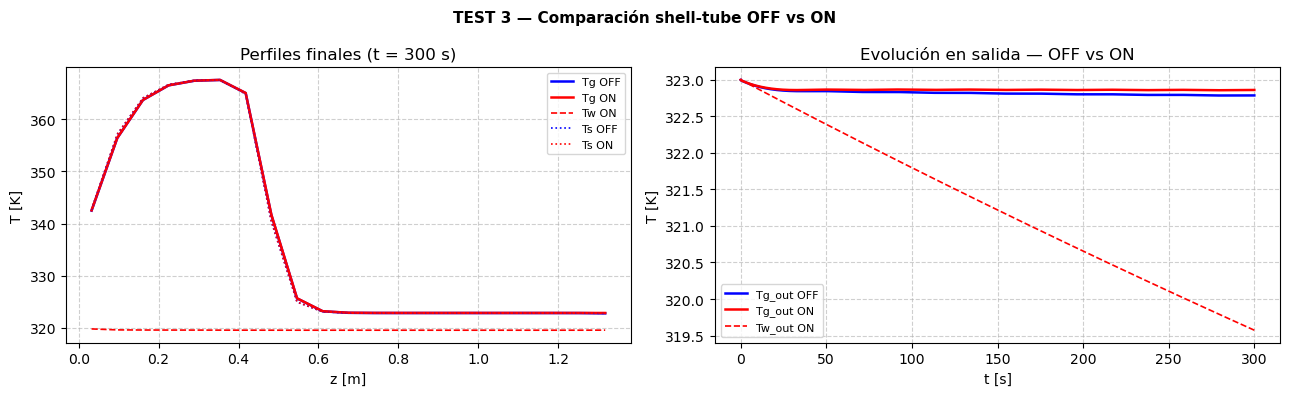

In [9]:
z_arr = c_off._z
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Perfiles finales
axes[0].plot(z_arr, c_off._Tg_results[-1], 'b-',  lw=1.8, label="Tg OFF")
axes[0].plot(z_arr, c_on._Tg_results[-1],  'r-',  lw=1.8, label="Tg ON")
axes[0].plot(z_arr, c_on._Tw_results[-1],  'r--', lw=1.2, label="Tw ON")
axes[0].plot(z_arr, c_off._Ts_results[-1], 'b:',  lw=1.2, label="Ts OFF")
axes[0].plot(z_arr, c_on._Ts_results[-1],  'r:',  lw=1.2, label="Ts ON")
axes[0].set_xlabel("z [m]"); axes[0].set_ylabel("T [K]")
axes[0].set_title(f"Perfiles finales (t = {T_MAX:.0f} s)")
axes[0].legend(fontsize=8); axes[0].grid(True, ls='--', alpha=0.6)

# Evolución temporal de Tg en salida
axes[1].plot(c_off._t_results, c_off._Tg_results[:, -1], 'b-',  lw=1.8, label="Tg_out OFF")
axes[1].plot(c_on._t_results,  c_on._Tg_results[:, -1],  'r-',  lw=1.8, label="Tg_out ON")
axes[1].plot(c_on._t_results,  c_on._Tw_results[:, -1],  'r--', lw=1.2, label="Tw_out ON")
axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("T [K]")
axes[1].set_title("Evolución en salida — OFF vs ON")
axes[1].legend(fontsize=8); axes[1].grid(True, ls='--', alpha=0.6)

fig.suptitle("TEST 3 — Comparación shell-tube OFF vs ON", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## TEST 4 — Conducción axial en la pared (siempre activa)

Tw inicializado con perfil escalonado (mitad izquierda fría, mitad derecha caliente).
Exterior adiabático para aislar el efecto de la difusión axial en la pared.

**Expectativa:** el rango axial de Tw disminuye con el tiempo por conducción axial
a través del metal (SS316L, k ≈ 16 W/m/K).

step=ads:   0%|          | 0.0/120 s [00:00<?, ?s/s]


Rango axial Tw inicial : 100.00 K
Rango axial Tw final   : 99.95 K
Conducción axial activa (rango decrece): True  ✓


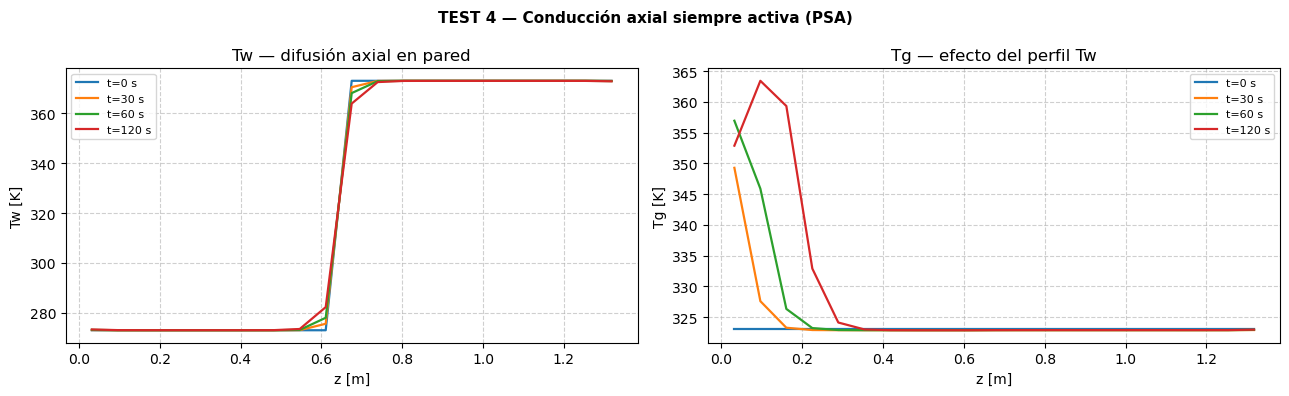

In [10]:
T_COLD = T_feed - 50.0   # K
T_HOT  = T_feed + 50.0   # K

Tw_step = np.where(np.arange(N) < N // 2, T_COLD, T_HOT).astype(float)

prop4, gTref4, ads4, tc4, tbc4, bc4 = _build_base_configs(mode_tbc="adiabatic")
wc4 = build_wall_config(
    N=N, Di=Di, Do=Do, T_w_init=Tw_step,
    material_id="SS316L", material_mode="polynomial", db_path=DB_SOLID,
)

init4 = build_initial_c_config(
    P_init=P_inlet * np.ones(N), Tg_init=T_feed * np.ones(N),
    Ts_init=T_feed * np.ones(N), y_init=y_init,
    n_comp=nc, N=N, iso_fn=ads4["iso"],
    prop_gas=prop4, epsi=epsi, gas_T_ref=gTref4, q_init=None,
)
sv0_4 = pack_state_vector(
    C=init4["C_init"], q=init4["q_init"],
    Hg=init4["Hg_init"], Ts=init4["Ts_init"],
    Tw=Tw_step,
)

T_MAX_4 = 120.0
params4 = _build_params(prop4, gTref4, ads4, tc4, tbc4, bc4, wall_config=wc4)

_, _, col4 = run_step(
    "ads", sv0_4, T_MAX_4, params4,
    rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)

dTw_init  = col4._Tw_results[0].max()  - col4._Tw_results[0].min()
dTw_final = col4._Tw_results[-1].max() - col4._Tw_results[-1].min()
print(f"\nRango axial Tw inicial : {dTw_init:.2f} K")
print(f"Rango axial Tw final   : {dTw_final:.2f} K")
print(f"Conducción axial activa (rango decrece): {dTw_final < dTw_init}  ✓")

z_arr = col4._z
plot_times_4 = [0.0, 30.0, 60.0, T_MAX_4]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for t_plot in plot_times_4:
    idx = np.argmin(np.abs(col4._t_results - t_plot))
    t_lbl = f"t={col4._t_results[idx]:.0f} s"
    axes[0].plot(z_arr, col4._Tw_results[idx], lw=1.6, label=t_lbl)
    axes[1].plot(z_arr, col4._Tg_results[idx], lw=1.6, label=t_lbl)

axes[0].set_title("Tw — difusión axial en pared"); axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("Tw [K]"); axes[0].legend(fontsize=8); axes[0].grid(True, ls='--', alpha=0.6)
axes[1].set_title("Tg — efecto del perfil Tw"); axes[1].set_xlabel("z [m]")
axes[1].set_ylabel("Tg [K]"); axes[1].legend(fontsize=8); axes[1].grid(True, ls='--', alpha=0.6)
fig.suptitle("TEST 4 — Conducción axial siempre activa (PSA)", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## TEST 5 — Compatibilidad regresiva sin `wall_config`

Cuando `wall_config=None`, el comportamiento debe ser idéntico al de `test_psa_01`:
sv de tamaño `2·nc·N + 2·N`, sin `_Tw_results`, balances iguales.

In [11]:
prop5, gTref5, ads5, tc5, tbc5, bc5 = _build_base_configs(
    mode_tbc="ambient_htc",
    h_ambi=250.0, T_ambi=298.0, k_wall=2.0,
)
init5 = build_initial_c_config(
    P_init=P_inlet * np.ones(N), Tg_init=T_feed * np.ones(N),
    Ts_init=T_feed * np.ones(N), y_init=y_init,
    n_comp=nc, N=N, iso_fn=ads5["iso"],
    prop_gas=prop5, epsi=epsi, gas_T_ref=gTref5, q_init=None,
)
sv0_5 = pack_state_vector(
    C=init5["C_init"], q=init5["q_init"],
    Hg=init5["Hg_init"], Ts=init5["Ts_init"],
    # Tw=None (default) → sin shell_tube
)

assert sv0_5.size == 2*nc*N + 2*N, f"ERROR sv size: {sv0_5.size} ≠ {2*nc*N + 2*N}"

params5 = _build_params(prop5, gTref5, ads5, tc5, tbc5, bc5, wall_config=None)
_, _, col5 = run_step(
    "ads", sv0_5, T_MAX, params5,
    rtol=RTOL, atol=ATOL, n_sec=N_SEC, show_progress=True,
)

has_Tw = hasattr(col5, "_Tw_results")
print(f"\nsv0 size sin wall_config: {sv0_5.size} = {2*nc*N + 2*N}  ✓")
print(f"_Tw_results presente: {has_Tw}  → debe ser False  ",
      "✓" if not has_Tw else "ERROR")
print(f"_Tg_results.shape  : {col5._Tg_results.shape}")
print(f"_Ts_results.shape  : {col5._Ts_results.shape}")
print()
print("Compatibilidad regresiva: OK")

# Verificar build_sv0_from_results funciona también sin shell_tube
sv_cont = build_sv0_from_results(col5)
assert sv_cont.size == sv0_5.size, f"ERROR continuación: {sv_cont.size} ≠ {sv0_5.size}"
print(f"build_sv0_from_results: sv_cont.size = {sv_cont.size}  ✓")

step=ads:   0%|          | 0.0/300 s [00:00<?, ?s/s]


sv0 size sin wall_config: 126 = 126  ✓
_Tw_results presente: False  → debe ser False   ✓
_Tg_results.shape  : (6001, 21)
_Ts_results.shape  : (6001, 21)

Compatibilidad regresiva: OK
build_sv0_from_results: sv_cont.size = 126  ✓


## 9. Resumen final

In [12]:
print("=" * 70)
print("  RESUMEN — PSA SHELL-TUBE")
print("=" * 70)
print()
print("TEST 1 — adiabático exterior:")
print(f"  _Tw_results presente : {hasattr(col1, '_Tw_results')}  ✓")
print(f"  Tw final (media axial): {col1._Tw_results[-1].mean():.2f} K")
print(f"  Tg final (media axial): {col1._Tg_results[-1].mean():.2f} K")
print()
print("TEST 2 — ambient_htc exterior:")
print(f"  Tg > Tw (pared pierde al ambiente): {bool(col2._Tg_results[-1].mean() > col2._Tw_results[-1].mean())}  ✓")
print(f"  Tg final: {col2._Tg_results[-1].mean():.2f} K  |  Tw final: {col2._Tw_results[-1].mean():.2f} K")
print()
print("TEST 3 — OFF vs ON:")
print(f"  Tg_out OFF: {c_off._Tg_results[-1].mean():.2f} K")
print(f"  Tg_out ON : {c_on._Tg_results[-1].mean():.2f} K")
print(f"  Diferencia: {abs(c_on._Tg_results[-1].mean() - c_off._Tg_results[-1].mean()):.3f} K")
print()
print("TEST 4 — Conducción axial siempre activa:")
print(f"  Rango axial Tw inicial : {col4._Tw_results[0].max() - col4._Tw_results[0].min():.2f} K")
print(f"  Rango axial Tw final   : {col4._Tw_results[-1].max() - col4._Tw_results[-1].min():.2f} K")
print(f"  Suavizado verificado   : {bool((col4._Tw_results[-1].max() - col4._Tw_results[-1].min()) < (col4._Tw_results[0].max() - col4._Tw_results[0].min()))}  ✓")
print()
print("TEST 5 — Compatibilidad regresiva: OK  ✓")
print("=" * 70)

  RESUMEN — PSA SHELL-TUBE

TEST 1 — adiabático exterior:
  _Tw_results presente : True  ✓
  Tw final (media axial): 323.02 K
  Tg final (media axial): 336.73 K

TEST 2 — ambient_htc exterior:
  Tg > Tw (pared pierde al ambiente): True  ✓
  Tg final: 336.73 K  |  Tw final: 319.58 K

TEST 3 — OFF vs ON:
  Tg_out OFF: 336.71 K
  Tg_out ON : 336.73 K
  Diferencia: 0.024 K

TEST 4 — Conducción axial siempre activa:
  Rango axial Tw inicial : 100.00 K
  Rango axial Tw final   : 99.95 K
  Suavizado verificado   : True  ✓

TEST 5 — Compatibilidad regresiva: OK  ✓
